In [1]:
from typing import TypedDict, List
from langchain_core.documents import Document


class GraphState(TypedDict):
    question: str
    documents: List[Document]
    answer: str
    confidence: float

In [2]:
RAG_PROMPT = """
You are a RAG assistant.

Answer ONLY using the provided context.

If the answer is not found in the context, respond:

"I couldn't find that information in the document."

Do not use any outside knowledge.

Context:
{context}

Question:
{question}
"""

In [4]:
from dotenv import load_dotenv
import os

# Load variables from .env
load_dotenv()

# Access environment variables
openrouter_api_key = os.getenv("OPENROUTER_API_KEY")
pinecone_api_key=os.getenv("PINECONE_API_KEY")
groq_Api_key = os.getenv("GROQ_API_KEY")

In [1]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "Qwen/Qwen3-Embedding-0.6B",
    trust_remote_code=True
)

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [ ]:
from pinecone import Pinecone
from langchain_pinecone import PineconeVectorStore

pc = Pinecone(api_key=pinecone_api_key)

index = pc.Index("agentic-ai")

vector_store = PineconeVectorStore(
    index=index,
    embedding=model
)

In [2]:
!pip install langchain-groq

  Using cached langchain_groq-1.1.3-py3-none-any.whl.metadata (2.9 kB)
  Using cached groq-0.37.1-py3-none-any.whl.metadata (16 kB)
Using cached langchain_groq-1.1.3-py3-none-any.whl (20 kB)
Using cached groq-0.37.1-py3-none-any.whl (137 kB)

   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 2/2 [langchain-groq]



In [7]:
from langchain_groq import ChatGroq

llm = ChatGroq(model='qwen/qwen3.6-27b',
               reasoning_effort="none")

In [8]:
#from prompts import RAG_PROMPT


def retrieve(state):
    question = state["question"]

    results = vector_store.similarity_search_with_score(
        question,
        k=4
    )

    docs = [doc for doc, score in results]
    confidence = max(score for _, score in results)

    return {
        "documents": docs,
        "confidence": confidence
    }


def generate(state):

    context = "\n\n".join(
        doc.page_content
        for doc in state["documents"]
    )

    prompt = RAG_PROMPT.format(
        context=context,
        question=state["question"]
    )

    response = llm.invoke(prompt)

    return {
        "answer": response.content
    }

In [9]:
!pip install langgraph

  Using cached langgraph_checkpoint-4.1.1-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_sdk-0.4.2-py3-none-any.whl.metadata (3.6 kB)
  Using cached ormsgpack-1.12.2-cp312-cp312-win_amd64.whl.metadata (3.3 kB)
  Using cached websockets-15.0.1-cp312-cp312-win_amd64.whl.metadata (7.0 kB)
Using cached langgraph_checkpoint-4.1.1-py3-none-any.whl (56 kB)
Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl (41 kB)
Using cached langgraph_sdk-0.4.2-py3-none-any.whl (160 kB)
Using cached websockets-15.0.1-cp312-cp312-win_amd64.whl (176 kB)
Using cached ormsgpack-1.12.2-cp312-cp312-win_amd64.whl (117 kB)

  Attempting uninstall: websockets

    Found existing installation: websockets 16.1.1

    Uninstalling websockets-16.1.1:

      Successfully uninstalled websockets-16.1.1

   ---------------------------------------- 0/6 [websockets]
   ------------- -------------------------- 2/6 [langgraph-sdk]
   ---

In [12]:
from typing import TypedDict, List
from langchain_core.documents import Document
class GraphState(TypedDict):
    question: str
    documents: List[Document]
    answer: str
    confidence: float

from langgraph.graph import StateGraph, START, END

#from state import GraphState
#from nodes import retrieve, generate

graph = StateGraph(GraphState)

graph.add_node("retrieve", retrieve)
graph.add_node("generate", generate)

graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", END)

chatbot = graph.compile()

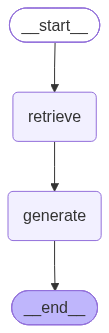

In [13]:
chatbot

In [17]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "Qwen/Qwen3-Embedding-0.6B",
    trust_remote_code=True
)

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [19]:

from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "Qwen/Qwen3-Embedding-0.6B",
    trust_remote_code=True
)

from pinecone import Pinecone
from langchain_pinecone import PineconeVectorStore

pc = Pinecone(api_key=pinecone_api_key)

index = pc.Index("agentic-ai")

vector_store = PineconeVectorStore(
    index=index,
    embedding=model
)

response = chatbot.invoke(
    {
        "question": "What is Agentic AI?"
    }
)

print(response["answer"])
print(response["confidence"])

for doc in response["documents"]:
    print(doc.page_content[:300])

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

AttributeError: 'SentenceTransformer' object has no attribute 'embed_query'